In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import lightkurve as lk
import astropy.units as u
import pmdarima as pm

from anesthetic import read_chains, make_2d_axes
from fgivenx import plot_contours, plot_lines
from lightkurve import LightCurve
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from nestar import model_comparison_utils as model_compare
from nestar import arima_results as ar
from nestar.ARIMA import ARIMA_fast, ARIMA_forecast

fs = 9
fig_width_pt = 244.0 # Get this from LaTeX using \showthe\columnwidth
inches_per_pt = 1.0/72.27               # Convert pt to inches
golden_mean = 0.6
fig_width = fig_width_pt*inches_per_pt  # width in inches
fig_height =fig_width*golden_mean       # height in inches
fig_size = [fig_width,fig_height]
fig_width_twocol_pt = 508.0 #for a two columns figure
fig_width_twocol = fig_width_twocol_pt*inches_per_pt
fig_height_twocol = fig_width_twocol*golden_mean

/Users/ajinkya/myenv/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


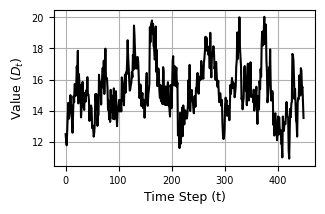

In [2]:
## Loading the simulated AR(2) time series.

series = np.loadtxt("ar2_sim_data.txt")
    
ar2_figure = plt.figure(figsize=(fig_width, fig_height))
plt.plot(series,color='black')
plt.xlabel(r'Time Step (t)',fontsize=fs)
plt.ylabel(r'Value ($D_t$)',fontsize=fs)
plt.tick_params(axis='both', labelsize=7)

plt.grid(True)
plt.show()
ar2_figure.savefig("Plots/ar2_simulated.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

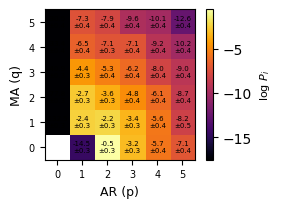

In [45]:
##Heatmap for simulated AR(2)
sim_ar2_heatmap = ar.EvidenceResults("Heatmap Data/sim_ar2_logPs_normal.txt",max_p=5,max_q=5)
sim_ar2_figure = sim_ar2_heatmap.plot_evidence_heatmap(contrast=115,fig_height=fig_height,fig_width=fig_width,title="",annotate_fontsize=5)
sim_ar2_figure.savefig("Plots/ar2_heatmap.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

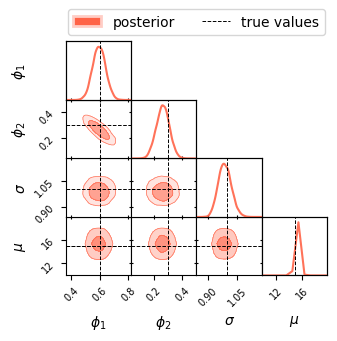

In [8]:
##Posteriors for ARIMA(2,0,0)
sim_ar2_samples_new = read_chains('NS Chains/simulated_ar2_samples_new.csv')
prior = sim_ar2_samples_new.prior()
params = ['phi_1','phi_2','sigma','mu']
sim_ar2_posteriors_fig, sim_ar2_posteriors_axes = make_2d_axes(params, figsize=(fig_width,1.5*fig_height), facecolor='w',upper=False)
sim_ar2_samples_new.plot_2d(sim_ar2_posteriors_axes, alpha=0.9,color='tomato',kinds='kde',label="posterior")
sim_ar2_posteriors_axes.axlines({'phi_1': 0.6, 'phi_2': 0.3, 'sigma': 1,'mu':14.87},
             c='black', linestyle='--', lw=0.7)
sim_ar2_posteriors_axes.iloc[-1, 0].axhline(y=14.87, c='black', linestyle='--', lw=0.7, label='true values')
sim_ar2_posteriors_axes.iloc[-1, 0].legend(bbox_to_anchor=(len(sim_ar2_posteriors_axes)/2, len(sim_ar2_posteriors_axes)), loc='lower center', ncols=2)
sim_ar2_posteriors_axes.iloc[-1,-1].set_xlim(9.87,19.87)
sim_ar2_posteriors_axes.tick_params(labelsize=7)

sim_ar2_posteriors_fig.savefig("Plots/ar2_posteriors.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

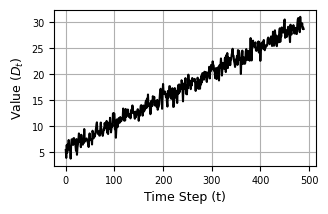

In [4]:
ts = np.loadtxt("simulated_trend_data.txt")

arima_313_figure = plt.figure(figsize=(fig_width, fig_height))
plt.plot(ts,color='black')
plt.xlabel(r'Time Step (t)',fontsize=fs)
plt.ylabel(r'Value ($D_t$)',fontsize=fs)
plt.tick_params(axis='both', labelsize=7)

plt.grid(True)
plt.show()
arima_313_figure.savefig("Plots/arima_313_data.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

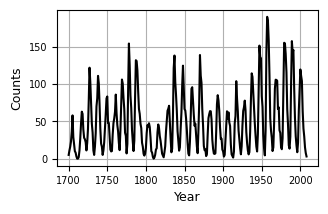

In [2]:
##Yearly Sunspots Number Data
dta = sm.datasets.sunspots.load_pandas().data
dta.index = pd.Index(sm.tsa.datetools.dates_from_range("1700", "2008"))
dta.index.freq = dta.index.inferred_freq
time = dta["YEAR"]
counts = dta['SUNACTIVITY'].to_numpy()
final_index = 255
training_dataset = counts[:final_index]
training_time = time[:final_index]

sunspots_data_fig, sunspots_axes = plt.subplots(1, 1, figsize=(fig_width, fig_height))
sunspots_axes.plot(time, counts, color='black')
sunspots_axes.set_xlabel('Year', fontsize=fs)
sunspots_axes.set_ylabel('Counts', fontsize=fs)
sunspots_axes.grid()
sunspots_axes.tick_params(axis='both', labelsize=7)
sunspots_data_fig.savefig("Plots/sunspots_number.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
/var/folders/rr/1tj80lxs6qs82kdts2zyymz80000gn/T/ipykernel_1351/1195002496.py:3: SyntaxWarning: invalid escape sequence '\D'
  sunspots_heatmap = sunspots_heatmap_data.compare(quantity2="net_prior_volume_effect",highlight_max=(False,False),invert=(False,False),fig_height=2*fig_height_twocol,fig_width=fig_width_twocol,fontsize=(5,5),title=("",""),cbar_label=(f"log $P_i$",f"$ \Delta \pi'$"),contrast=(80,-2))


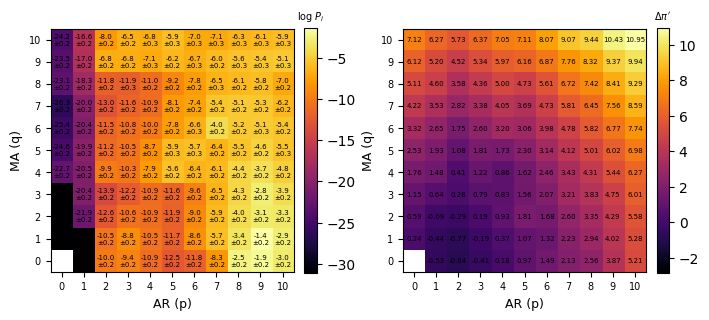

In [3]:
##Sunspots heatmap
sunspots_heatmap_data = ar.EvidenceResults("Heatmap Data/sunspots_logP.txt",max_p=10,max_q=10)
sunspots_heatmap = sunspots_heatmap_data.compare(quantity2="net_prior_volume_effect",highlight_max=(False,False),invert=(False,False),fig_height=2*fig_height_twocol,fig_width=fig_width_twocol,fontsize=(5,5),title=("",""),cbar_label=(f"log $P_i$",f"$ \Delta \pi'$"),contrast=(80,-2))
sunspots_heatmap.savefig("Plots/sunspot_heatmap_arima.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

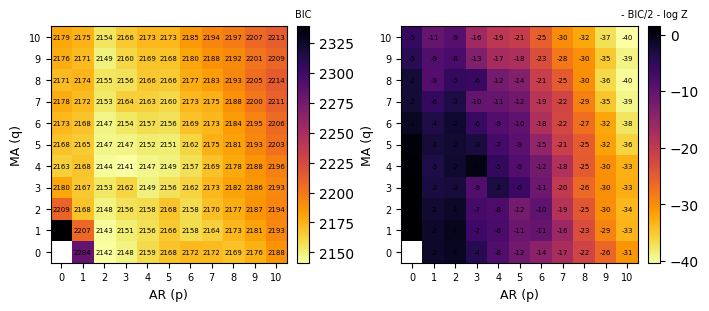

In [4]:
BIC = sunspots_heatmap_data._quantity("BIC")
logZ,err = sunspots_heatmap_data._quantity("evidences")
BIC_2 = -1* BIC[0]/2
comparison_heatmap = sunspots_heatmap_data.compare(quantity1=BIC[0],quantity2= BIC_2 - logZ,fig_height=2*fig_height_twocol,fig_width=fig_width_twocol,
                                                   fontsize=(5,5),value_fmt=("{:.0f}","{:.0f}"),invert=(True,True),title=("",""),
                                                   cbar_label=("BIC","- BIC/2 - log Z"),contrast=(0,0))

comparison_heatmap.savefig("Plots/sunspot_BIC_lnZ_compare.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
/var/folders/rr/1tj80lxs6qs82kdts2zyymz80000gn/T/ipykernel_1351/3628510738.py:1: SyntaxWarning: invalid escape sequence '\D'
  D0_occam = sunspots_heatmap_data.compare(quantity1="log_V_boost",quantity2="d0_occam",value_fmt=("{:.1f}","{:.1f}"),fig_height=2*fig_height_twocol,fig_width=fig_width_twocol,title=("",""),cbar_label=(f"log V", f"$\Delta D_0$"),contrast=(-5.93,-8),invert=(False,False))


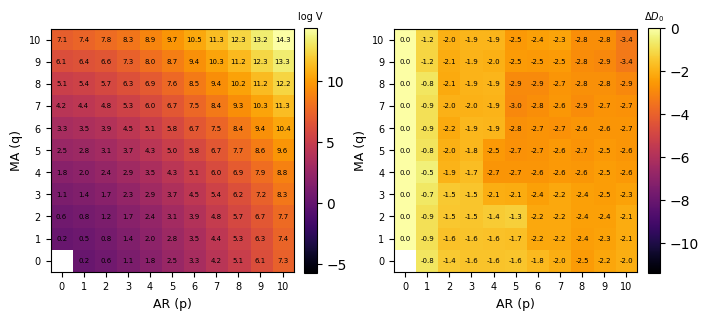

In [29]:
D0_occam = sunspots_heatmap_data.compare(quantity1="log_V_boost",quantity2="d0_occam",value_fmt=("{:.1f}","{:.1f}"),fig_height=2*fig_height_twocol,fig_width=fig_width_twocol,title=("",""),cbar_label=(f"log V", f"$\Delta D_0$"),contrast=(-5.93,-8),invert=(False,False))
D0_occam.savefig("Plots/logV_D0.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

PosteriorResults: order=(9, 0, 1), prior_type='normal' (inferred from chain)


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

/Users/ajinkya/Desktop/ARIMA-Nested-Sampling 2/arima_results.py:1010: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.3)


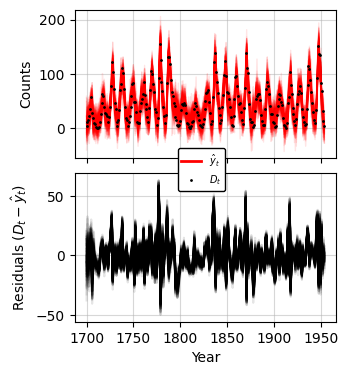

In [3]:
sp_91_posteriors = ar.PosteriorResults("NS Chains/sunspots_arma91_samples_new.csv",train_data=training_dataset)
sp91_figure,fit_data = sp_91_posteriors.insample_forecast(training_time,5000,33,ylabel="Counts",xlabel="Year",figsize=(fig_width,2*fig_height),deterministic=False)
sp91_figure.savefig("Plots/sunspots_fit_resid.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

Pooled residuals: 100%|██████████| 5000/5000 [00:01<00:00, 2509.46it/s]


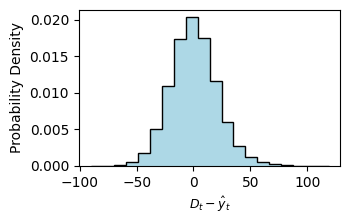

In [4]:
sp_pooled_residuals = sp_91_posteriors.pooled_residuals(n_samples=5000,deterministic=False).flatten()
pooled_resids_hist = plt.figure(figsize=(fig_width,fig_height))
plt.hist(sp_pooled_residuals,bins=20,density=True,histtype='step',color='black')
plt.hist(sp_pooled_residuals,bins=20,density=True,color='lightblue')
plt.xlabel(r'$D_t - \hat{y}_t$',fontsize=9)
plt.ylabel('Probability Density')
pooled_resids_hist.savefig("Plots/sunspots_resid_hist.pdf", bbox_inches="tight", dpi=300, pad_inches=0.02,transparent=True, format="pdf")

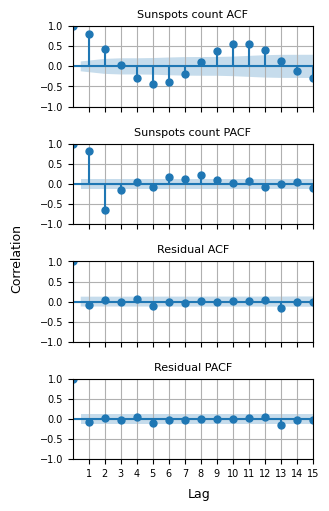

In [5]:
sp_point_forecast = sp_91_posteriors.point_estimate_forecast()
sp_mean_resids = sp_point_forecast['residuals']


sunspots_acf, sunspots_acf_ax = plt.subplots(4, 1, figsize=(fig_width, 1.25*fig_height_twocol), sharex=True)
plot_acf(training_dataset, ax=sunspots_acf_ax[0], title="Sunspots count ACF")
plot_pacf(training_dataset, ax=sunspots_acf_ax[1], title="Sunspots count PACF")
plot_acf(sp_mean_resids, ax=sunspots_acf_ax[2], title="Residual ACF")
plot_pacf(sp_mean_resids, ax=sunspots_acf_ax[3], title="Residual PACF")
sunspots_acf_ax[0].set_xlim(0, 15)

for i, ax in enumerate(sunspots_acf_ax):
    ax.grid()
    ax.title.set_fontsize(8)
    ax.tick_params(axis='both', labelsize=7)
    ax.set_xticks(range(1, 16))
    ax.set_yticks([-1.0,-0.5,0.0,0.5,1.0])
    if i > 0:
        ax.title.set_position([0.5, -0.15])

sunspots_acf.supylabel('Correlation', fontsize=fs, x=0.04)
sunspots_acf.supxlabel('Lag', fontsize=fs, y=0.04, x=0.6)
plt.tight_layout()
plt.show()
sunspots_acf.savefig("Plots/sunspots_acf.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

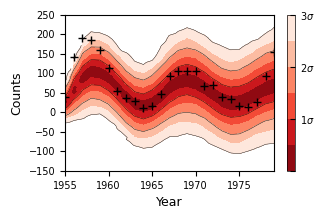

In [ ]:
##ARIMA(9,0,1) predictive posterior forecasts
sp_arma_91_samples = read_chains("NS Chains/sunspots_arma91_samples_new.csv")
sunspot_forecast_fig, sunspot_forecast_ax = plt.subplots(1, 1, figsize=(fig_width, fig_height), sharey=True)

def arma91_forecast_func(x, params):
    phis = params[0:9]
    thetas = params[9:10]
    sigma = params[10]
    mu = params[11]
    init_y = params[12:21]
    seed = int(params[21])
    y_model = ARIMA_forecast(training_dataset, (9,0,1), sigma, mu, phis, thetas, num_forecast, init_y, seed)
    return y_model

np.random.seed(33)
seeds_91_forecast = np.random.randint(0, 1000000, size=10000)
arma91_forecast_samples = sp_arma_91_samples.sample(10000)
phi_1 = arma91_forecast_samples['phi_1']
phi_2 = arma91_forecast_samples['phi_2']
phi_3 = arma91_forecast_samples['phi_3']
phi_4 = arma91_forecast_samples['phi_4']
phi_5 = arma91_forecast_samples['phi_5']
phi_6 = arma91_forecast_samples['phi_6']
phi_7 = arma91_forecast_samples['phi_7']
phi_8 = arma91_forecast_samples['phi_8']
phi_9 = arma91_forecast_samples['phi_9']
theta_1 = arma91_forecast_samples['theta_1']
sigma = arma91_forecast_samples['sigma']
mean = arma91_forecast_samples['mu']
init_y1 = arma91_forecast_samples['init_y_1']
init_y2 = arma91_forecast_samples['init_y_2']
init_y3 = arma91_forecast_samples['init_y_3']
init_y4 = arma91_forecast_samples['init_y_4']
init_y5 = arma91_forecast_samples['init_y_5']
init_y6 = arma91_forecast_samples['init_y_6']
init_y7 = arma91_forecast_samples['init_y_7']
init_y8 = arma91_forecast_samples['init_y_8']
init_y9 = arma91_forecast_samples['init_y_9']
better_forecast_samples = [(p1,p2,p3,p4,p5,p6,p7,p8,p9,t1,sig,mu,iy1,iy2,iy3,iy4,iy5,iy6,iy7,iy8,iy9,sf) for p1,p2,p3,p4,p5,p6,p7,p8,p9,t1,sig,mu,iy1,iy2,iy3,iy4,iy5,iy6,iy7,iy8,iy9,sf in zip(phi_1,phi_2,phi_3,phi_4,phi_5,phi_6,phi_7,phi_8,phi_9,theta_1,sigma,mean,init_y1,init_y2,init_y3,init_y4,init_y5,init_y6,init_y7,init_y8,init_y9,seeds_91_forecast)]

num_forecast = 25
cbar = plot_contours(f=arma91_forecast_func, x=time[final_index:final_index+num_forecast], samples=better_forecast_samples, ax=sunspot_forecast_ax)
cbar = plt.colorbar(cbar, ticks=[0,1,2,3], ax=sunspot_forecast_ax)
cbar.set_ticklabels(["", r"$1\sigma$", r"$2\sigma$", r"$3\sigma$"])
cbar.ax.tick_params(labelsize=7, direction="in")
cbar.outline.set_linewidth(0.5)
cbar.ax.yaxis.set_ticks_position('right')
sunspot_forecast_ax.set_xlabel('Year', fontsize=9)
sunspot_forecast_ax.set_ylabel('Counts', fontsize=9)
sunspot_forecast_ax.plot(time[final_index:final_index+num_forecast], counts[final_index:final_index+num_forecast], marker='+', lw=0, color='black', label='Observed Counts')
sunspot_forecast_ax.set_ylim(-150, 250)
sunspot_forecast_ax.tick_params(axis='both', labelsize=7)
sunspot_forecast_fig.savefig("Plots/sunspots_forecast.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

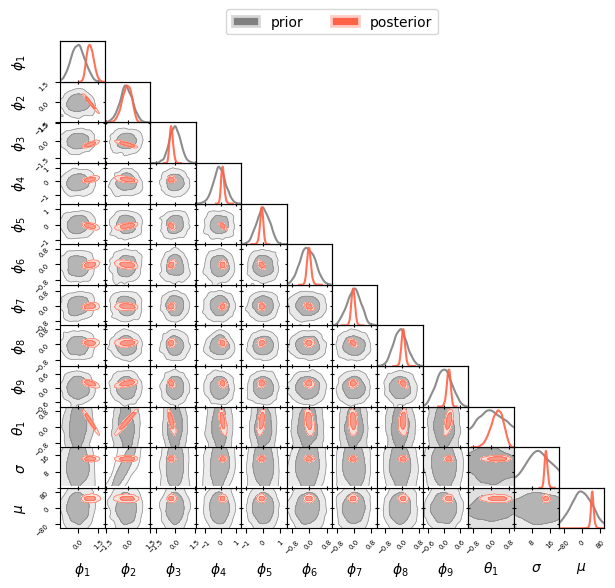

In [16]:
##ARIMA(9,0,1) posteriors
sp_arma_91_samples = read_chains("NS Chains/sunspots_arma91_samples_new.csv")
prior = sp_arma_91_samples.prior()
params = ['phi_1','phi_2','phi_3','phi_4','phi_5','phi_6','phi_7','phi_8','phi_9','theta_1','sigma','mu']
posterior_fig, posterior_axes = make_2d_axes(params, figsize=(fig_width_twocol, 1.5*fig_height_twocol), facecolor='w',upper=False)
prior.plot_2d(posterior_axes, alpha=0.9, label="prior",color='gray')
sp_arma_91_samples.plot_2d(posterior_axes, alpha=0.9, label="posterior",color='tomato',kind='kde')
posterior_axes.iloc[-2,-2].set_xlim(0,20)
posterior_axes.iloc[-1,-1].set_xlim(-100,100)
posterior_axes.tick_params(labelsize=5)

posterior_axes.iloc[-1, 0].legend(bbox_to_anchor=(len(posterior_axes)/2, len(posterior_axes)), loc='lower center', ncols=2)
posterior_fig.savefig("Plots/sunspots_full_posteriors.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

PosteriorResults: order=(5, 0, 4), prior_type='pacf' (inferred from chain)
PosteriorResults: order=(3, 0, 4), prior_type='normal' (inferred from chain)


NS forecast samples: 100%|██████████| 10000/10000 [01:07<00:00, 148.95it/s]


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

--- Forecast summary: ARIMA(9, 0, 1) (normal prior), h=25 ---
nested      : RMSE=39.469  MAE=27.583  LPD=-132.58  skill_vs_clim=0.381  skill_vs_pers=0.568
climatology : RMSE=63.737  MAE=48.042  LPD=-152.66
persistence : RMSE=91.333  MAE=73.156  LPD=-195.34


...

--- Forecast summary: ARIMA(5, 0, 4) (pacf prior), h=25 ---
nested      : RMSE=44.911  MAE=31.889  LPD=-140.33  skill_vs_clim=0.295  skill_vs_pers=0.508
climatology : RMSE=63.737  MAE=48.042  LPD=-152.66
persistence : RMSE=91.333  MAE=73.156  LPD=-195.34


NS forecast samples: 100%|██████████| 10000/10000 [01:06<00:00, 149.40it/s]


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

--- Forecast summary: ARIMA(3, 0, 4) (normal prior), h=25 ---
nested      : RMSE=56.582  MAE=41.409  LPD=-145.25  skill_vs_clim=0.112  skill_vs_pers=0.380
climatology : RMSE=63.737  MAE=48.042  LPD=-152.66
persistence : RMSE=91.333  MAE=73.156  LPD=-195.34


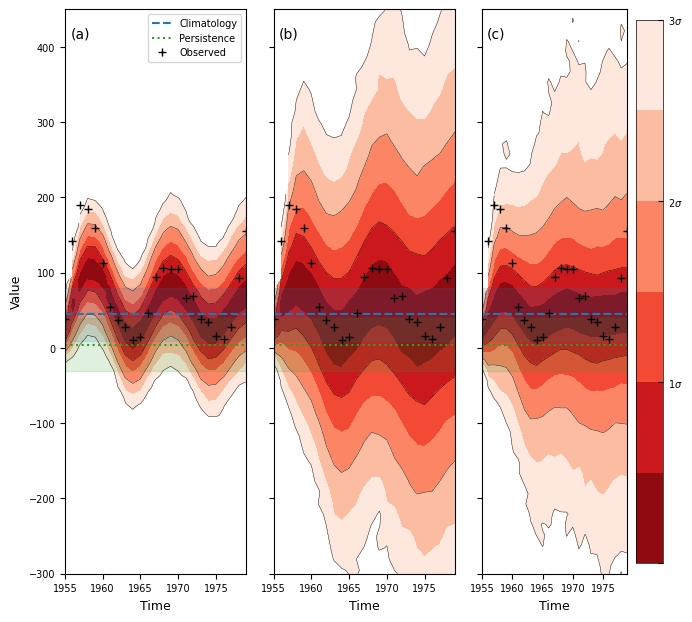

In [5]:
sp_54_posteriors = ar.PosteriorResults("NS Chains/sunspots_arma54_samples_new.csv",train_data=training_dataset)
sp_34_posteriors = ar.PosteriorResults("NS Chains/sunspots_arma34_samples_new.csv",train_data=training_dataset)

forecast_compare_fig, forecast_compare_ax = plt.subplots(
    1, 3,
    figsize=(fig_width_twocol, 1.5*fig_height_twocol),
    sharey=True
)

sp_91_posteriors.outsample_forecast(
    time,
    counts,
    25,
    upper_index=255,
    n_samples=10000,
    seed=33,
    ax=forecast_compare_ax[0],
    ylim=(-300, 450),
    show_legend=True,
    show_title=False,
    show_colorbar=False
)

sp_54_posteriors.outsample_forecast(
    time,
    counts,
    25,
    upper_index=255,
    n_samples=10000,
    seed=33,
    ax=forecast_compare_ax[1],
    ylim=(-300, 400),
    show_legend=False,
    show_title=False,
    show_colorbar=False,
    ylabel=""
)

sp_34_posteriors.outsample_forecast(
    time,
    counts,
    25,
    upper_index=255,
    n_samples=10000,
    seed=33,
    ax=forecast_compare_ax[2],
    ylim=(-300, 450),
    show_legend=False,
    show_title=False,
    ylabel=""
)

# Panel labels
forecast_compare_ax[0].text(
    0.03, 0.95, '(a)',
    transform=forecast_compare_ax[0].transAxes
)

forecast_compare_ax[1].text(
    0.03, 0.95, '(b)',
    transform=forecast_compare_ax[1].transAxes
)

forecast_compare_ax[2].text(
    0.03, 0.95, '(c)',
    transform=forecast_compare_ax[2].transAxes

)
xticks = [1955, 1960, 1965, 1970, 1975]

for ax in forecast_compare_ax:
    ax.set_xticks(xticks)
forecast_compare_fig.tight_layout()

forecast_compare_fig.savefig(
    "Plots/sunspots_forecast_compare.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True,
    format="pdf"
)

plt.show()

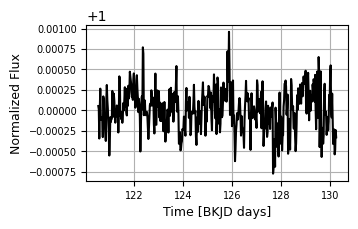

In [6]:
kic12008916_lc = lk.search_lightcurve('KIC 12008916')[0].download().remove_outliers(sigma=5).normalize()
flux_var = np.array(kic12008916_lc['flux'].value, dtype=np.float64)
flux_err_var = np.array(kic12008916_lc['flux_err'].value)
time_var = np.array(kic12008916_lc['time'].value)

kic12008916_fig, kic12008916_ax = plt.subplots(1, 1, figsize=(fig_width, fig_height), sharey=True)
kic12008916_ax.plot(time_var, flux_var, c='black')
kic12008916_ax.set_xlabel('Time [BKJD days]', fontsize=fs)
kic12008916_ax.set_ylabel('Normalized Flux', fontsize=fs)
kic12008916_ax.grid()
kic12008916_ax.tick_params(axis='both', labelsize=7)
kic12008916_fig.savefig("Plots/kic_12008916_lc.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

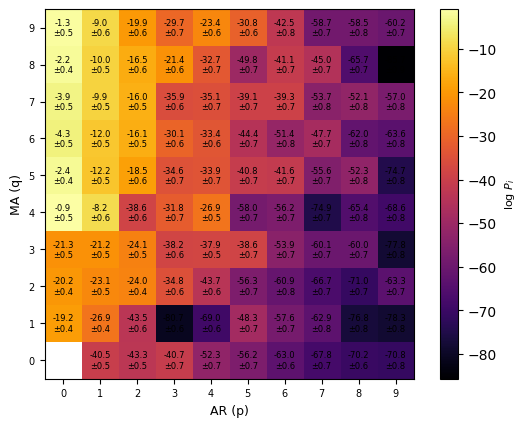

In [9]:
kic12008916_heatmap_data = ar.EvidenceResults("Heatmap Data/KIC_12008916_evidences_max.txt",max_p=9,max_q=9)
kic12008916_heatmap = kic12008916_heatmap_data.plot_evidence_heatmap(fig_height=fig_height_twocol,fig_width=fig_width_twocol,annotate_fontsize=6)
kic12008916_heatmap.savefig("Plots/kic_12008916_heatmap.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

PosteriorResults: order=(0, 0, 4), prior_type='normal' (inferred from chain)


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

/Users/ajinkya/Desktop/ARIMA-Nested-Sampling 2/arima_results.py:1010: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.3)


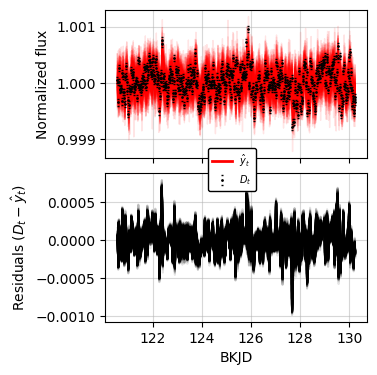

In [11]:
kic12008916_posterior = ar.PosteriorResults("NS Chains/old/KIC_12008916_samples.csv",flux_var)
kic12008916_forecast_fig,kic12008916_data = kic12008916_posterior.insample_forecast(time_var,n_samples=5000,seed=33,ylabel="Normalized flux",xlabel="BKJD",meas_sigma=flux_err_var,figsize=(fig_width,2*fig_height),alpha=1,ms=1,capsize=1,deterministic=False)
kic12008916_forecast_fig.savefig("Plots/kic_12008916_forecast.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

Pooled residuals: 100%|██████████| 1000/1000 [00:00<00:00, 2567.22it/s]


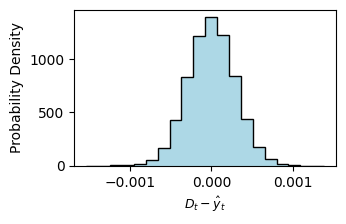

In [12]:
kic12008196_pooled_resid = kic12008916_posterior.pooled_residuals(deterministic=False).flatten()
kic_pooled_resids_hist = plt.figure(figsize=(fig_width,fig_height))
plt.hist(kic12008196_pooled_resid,bins=20,density=True,histtype='step',color='black')
plt.hist(kic12008196_pooled_resid,bins=20,density=True,color='lightblue')
plt.xlabel(r'$D_t - \hat{y}_t$',fontsize=9)
plt.ylabel('Probability Density')
kic_pooled_resids_hist.savefig("Plots/kic12008916_resid_hist.pdf", bbox_inches="tight", dpi=300, pad_inches=0.02,transparent=True, format="pdf")

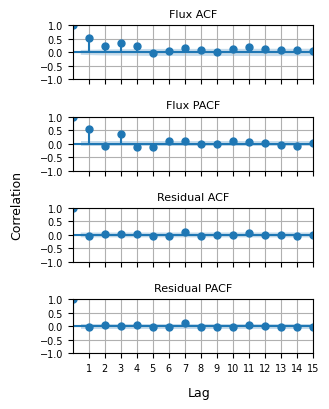

In [13]:
kic12008916_point_estimate = kic12008916_posterior.point_estimate_forecast()
kic12008916_mean_resid = kic12008916_point_estimate["residuals"]

kic_12008916_acf, kic_12008916_acf_ax = plt.subplots(4, 1, figsize=(fig_width,fig_height_twocol), sharex=True)

plot_acf(flux_var, ax=kic_12008916_acf_ax[0], title="Flux ACF")
plot_pacf(flux_var, ax=kic_12008916_acf_ax[1], title="Flux PACF")
plot_acf(kic12008916_mean_resid, ax=kic_12008916_acf_ax[2], title="Residual ACF")
plot_pacf(kic12008916_mean_resid, ax=kic_12008916_acf_ax[3], title="Residual PACF")
kic_12008916_acf_ax[0].set_xlim(0, 15)

for i, ax in enumerate(kic_12008916_acf_ax):
    ax.grid()
    ax.title.set_fontsize(8)
    ax.tick_params(axis='both', labelsize=7)
    ax.set_xticks(range(1, 16))
    ax.set_yticks([-1.0,-0.5,0.0,0.5,1.0])
    if i > 0:
        ax.title.set_position([0.5, -0.15])

kic_12008916_acf.supylabel('Correlation', fontsize=fs, x=0.04)
kic_12008916_acf.supxlabel('Lag', fontsize=fs, y=0.04, x=0.6)
plt.tight_layout()
plt.show()
kic_12008916_acf.savefig("Plots/kic_12008916_acf.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

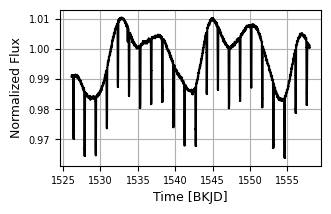

In [14]:
kepler_17_lc = lk.search_lightcurve('Kepler 17', mission='Kepler')[40].download().remove_outliers(sigma=5).normalize().remove_nans().bin(time_bin_size=0.02111501723265975*u.day)
k17_flux = np.array(kepler_17_lc['flux'].value)
k17_flux_err = np.array(kepler_17_lc['flux_err'].value)
k17_time = np.sort(np.array(kepler_17_lc['time'].value))

kepler17_fig, kepler17_ax = plt.subplots(figsize=(fig_width, fig_height))
kepler17_ax.errorbar(k17_time, k17_flux, yerr=k17_flux_err, c='black')
kepler17_ax.set_xlabel('Time [BKJD]', fontsize=fs)
kepler17_ax.set_ylabel('Normalized Flux', fontsize=fs)
kepler17_ax.grid()
kepler17_ax.tick_params(axis='both', labelsize=7)
kepler17_fig.savefig("Plots/kepler_17_lc.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

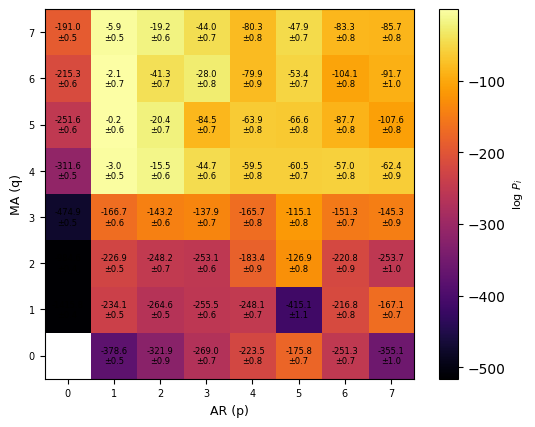

In [29]:
kepler17_heatmap_data = ar.EvidenceResults("Heatmap Data/kepler17_d1.txt",max_p=7,max_q=7)
k17_heatmap = kepler17_heatmap_data.plot_evidence_heatmap(fig_height=fig_height_twocol,fig_width=fig_width_twocol,annotate_fontsize=6,contrast=900)
k17_heatmap.savefig("Plots/kepler17_heatmap.pdf",bbox_inches="tight",dpi=300,transparent=True,format="pdf")

PosteriorResults: order=(1, 1, 5), prior_type='normal' (inferred from chain)


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

/Users/ajinkya/Desktop/ARIMA-Nested-Sampling 2/arima_results.py:1010: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.3)


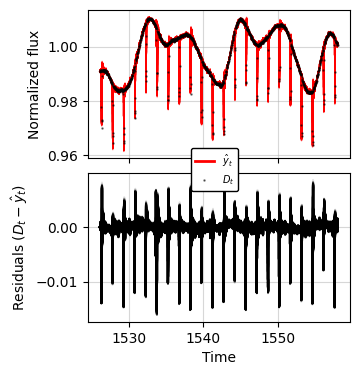

In [17]:
k17_posteriors = ar.PosteriorResults("NS Chains/kepler_17_samples.csv",train_data=k17_flux,d=1)
k17_insample_fig,k17_data= k17_posteriors.insample_forecast(k17_time,n_samples=5000,seed=33,ylabel=f"Normalized flux",meas_sigma=k17_flux_err,figsize=(fig_width,2*fig_height),alpha=0.5,ms=0.8,capsize=0)
k17_insample_fig.savefig("Plots/kepler17_fit.pdf",bbox_inches="tight",dpi=300,transparent=True,format="pdf")

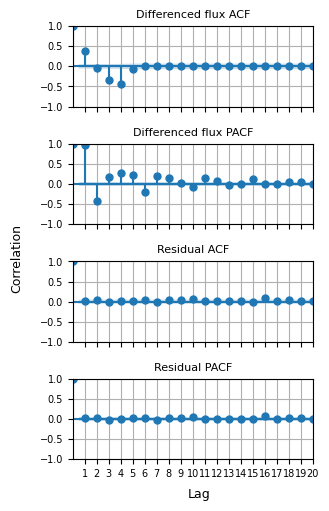

In [34]:
k17_point_estimate = k17_posteriors.point_estimate_forecast()
k17_mean_resid = k17_point_estimate["residuals"]
k17_acf, k17_acf_ax = plt.subplots(4, 1, figsize=(fig_width, 1.25*fig_height_twocol), sharex=True)
plot_acf(np.diff(k17_flux), ax=k17_acf_ax[0], title="Differenced flux ACF")
plot_pacf(k17_flux, ax=k17_acf_ax[1], title="Differenced flux PACF")
plot_acf(k17_mean_resid, ax=k17_acf_ax[2], title="Residual ACF")
plot_pacf(k17_mean_resid, ax=k17_acf_ax[3], title="Residual PACF")
k17_acf_ax[0].set_xlim(0, 20)

for i, ax in enumerate(k17_acf_ax):
    ax.grid()
    ax.title.set_fontsize(8)
    ax.tick_params(axis='both', labelsize=7)
    ax.set_xticks(range(1, 21))
    ax.set_yticks([-1.0,-0.5,0.0,0.5,1.0])
    if i > 0:
        ax.title.set_position([0.5, -0.15])

k17_acf.supylabel('Correlation', fontsize=fs, x=0.04)
k17_acf.supxlabel('Lag', fontsize=fs, y=0.04, x=0.6)
plt.tight_layout()
plt.show()
k17_acf.savefig("Plots/k17_acf.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

Pooled residuals: 100%|██████████| 1000/1000 [00:00<00:00, 2456.67it/s]


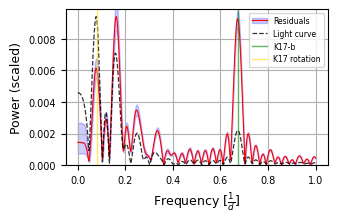

In [21]:
pooled_resids = k17_posteriors.pooled_residuals()
freq = np.linspace(0.001, 1, 1000)
power_matrix = np.array([
LightCurve(time=k17_time, flux=r).to_periodogram(frequency=freq).power.value
for r in pooled_resids
])
median_power = np.median(power_matrix, axis=0)
lo, hi = np.percentile(power_matrix, [16, 84], axis=0)
lightcurve_power = kepler_17_lc.to_periodogram(frequency=freq).power.value
scale_factor = lightcurve_power.max() / median_power.max()
median_power_scaled = median_power * scale_factor
lo_scaled = lo * scale_factor
hi_scaled = hi * scale_factor
k17_pg_fig,ax = plt.subplots(1,1,figsize=(fig_width,fig_height))
resid_line, = ax.plot(freq, median_power_scaled, color='red',lw=0.8)
resid_band = ax.fill_between(freq, lo_scaled, hi_scaled, alpha=0.2, color='blue')
ax.plot(freq,lightcurve_power,color='black',alpha=0.8,linestyle="--",lw=0.9,label='Light curve')
ax.axvline(1/1.4857, lw=1, c='green',alpha=0.6,label='K17-b')
ax.axvline(1/12, lw=1, c='gold',alpha=0.6,label='K17 rotation')

ax.set_ylim(0,lightcurve_power.max()*1.05)
ax.set_xlabel(r'Frequency [$\frac{1}{d}$]', fontsize=fs)
ax.set_ylabel(r'Power (scaled)', fontsize=fs)
ax.tick_params(axis='both', which='major', labelsize=7)
ax.tick_params(axis='both', which='minor', labelsize=6)
handles, labels = ax.get_legend_handles_labels()
handles.insert(0,(resid_band,resid_line))
labels.insert(0,'Residuals')
plt.legend(handles,labels,fontsize=5.5,loc="upper right")
plt.grid()
plt.show()
k17_pg_fig.savefig("Plots/kepler_17_pg.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

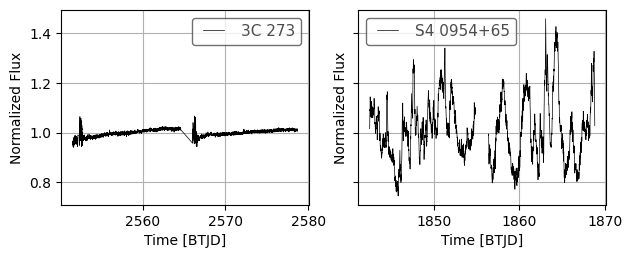

In [22]:
quasar_lc = lk.search_lightcurve('3C 273')[8].download().remove_outliers(sigma=5).normalize().remove_nans()
blazar_lc = lk.search_lightcurve('S4 0954+65')[0].download().remove_outliers(sigma=5).normalize().remove_nans().bin(time_bin_size=0.014*u.day)
quasars_lc_fig,quasars_lc_ax = plt.subplots(1,2,figsize=(fig_width_twocol,0.6*fig_height_twocol),sharey=True)
quasar_lc.plot(ax=quasars_lc_ax[0],c='black',label='3C 273')
blazar_lc.plot(ax=quasars_lc_ax[1],c='black',label='S4 0954+65')
quasars_lc_ax[0].grid()
quasars_lc_ax[0].set_xlabel('Time [BTJD]')
quasars_lc_ax[1].set_xlabel('Time [BTJD]')

quasars_lc_ax[1].grid()
quasars_lc_fig.savefig("Plots/quasar_lcs_fig.pdf",bbox_inches="tight",dpi=300,transparent=True,format="pdf")

In [23]:
quasar_flux = np.array(quasar_lc['flux'].value)
quasar_flux_err = np.array(quasar_lc['flux_err'].value)
quasar_time = np.sort(np.array(quasar_lc['time'].value))
quasar_time = quasar_time[120:1730]
quasar_flux = quasar_flux[120:1730]
quasar_flux_err = quasar_flux_err[120:1730]

blazar_flux_total = np.array(blazar_lc['flux'].value)
blazar_flux_err = np.array(blazar_lc['flux_err'].value)
blazar_time_total = np.sort(np.array(blazar_lc['time'].value))
blazar_time = blazar_time_total[:850]
blazar_flux = blazar_flux_total[:850]
blazar_flux_err = blazar_flux_err[:850]

PosteriorResults: order=(1, 1, 1), prior_type='normal' (inferred from chain)


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

/Users/ajinkya/Desktop/ARIMA-Nested-Sampling 2/arima_results.py:1010: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.3)


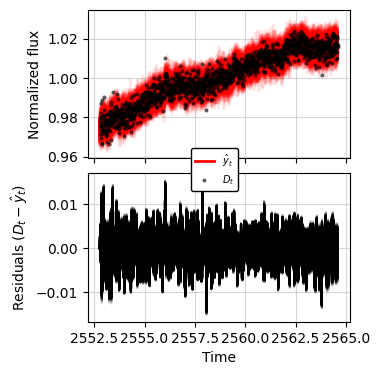

In [46]:
quasar_posteriors = ar.PosteriorResults("NS Chains/old/3C_273_samples.csv",quasar_flux,d=1)
quasar_insample,quasar_data = quasar_posteriors.insample_forecast(quasar_time,n_samples=5000,seed=33,ylabel=f"Normalized flux",figsize=(fig_width,2*fig_height),alpha=0.5,ms=2,capsize=2,lw=2,deterministic=False)
quasar_insample.savefig("Plots/quasar_resid.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

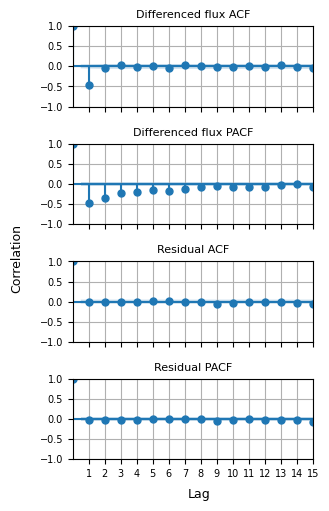

In [9]:
quasar_residual = quasar_posteriors.point_estimate_forecast()['residuals']

quasar_acf, quasar_acf_ax = plt.subplots(4, 1, figsize=(fig_width, 1.25*fig_height_twocol), sharex=True)
plot_acf(np.diff(quasar_flux), ax=quasar_acf_ax[0], title="Differenced flux ACF")
plot_pacf(np.diff(quasar_flux), ax=quasar_acf_ax[1], title="Differenced flux PACF")
plot_acf(quasar_residual, ax=quasar_acf_ax[2], title="Residual ACF")
plot_pacf(quasar_residual, ax=quasar_acf_ax[3], title="Residual PACF")
quasar_acf_ax[0].set_xlim(0, 15)

for i, ax in enumerate(quasar_acf_ax):
    ax.grid()
    ax.title.set_fontsize(8)
    ax.tick_params(axis='both', labelsize=7)
    ax.set_xticks(range(1, 16))
    ax.set_yticks([-1.0,-0.5,0.0,0.5,1.0])
    if i > 0:
        ax.title.set_position([0.5, -0.15])

quasar_acf.supylabel('Correlation', fontsize=fs, x=0.04)
quasar_acf.supxlabel('Lag', fontsize=fs, y=0.04, x=0.6)
plt.tight_layout()
plt.show()
quasar_acf.savefig("Plots/quasar_acf.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

PosteriorResults: order=(1, 1, 2), prior_type='normal' (inferred from chain)


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

/Users/ajinkya/Desktop/ARIMA-Nested-Sampling 2/arima_results.py:1010: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.3)


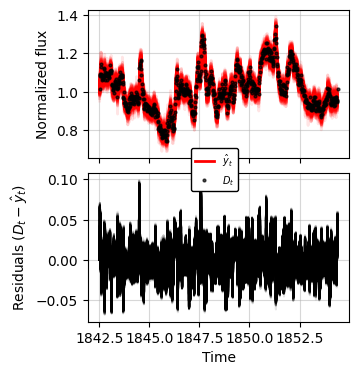

In [47]:
blazar_posteriors = ar.PosteriorResults("NS Chains/S4_0954+65_samples.csv",blazar_flux,d=1)
blazar_insample,blazar_data = blazar_posteriors.insample_forecast(blazar_time,n_samples=5000,seed=33,ylabel=f"Normalized flux",figsize=(fig_width,2*fig_height),deterministic=False,alpha=0.7,ms=2,lw=2)
blazar_insample.savefig("Plots/blazar_resid.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

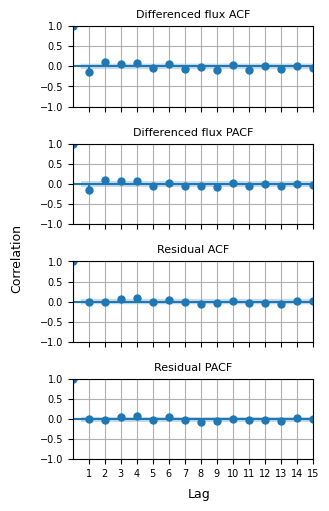

In [32]:
blazar_residual = blazar_posteriors.point_estimate_forecast()['residuals']
blazar_acf, blazar_acf_ax = plt.subplots(4, 1, figsize=(fig_width, 1.25*fig_height_twocol), sharex=True)
plot_acf(np.diff(blazar_flux), ax=blazar_acf_ax[0], title="Differenced flux ACF")
plot_pacf(np.diff(blazar_flux), ax=blazar_acf_ax[1], title="Differenced flux PACF")
plot_acf(blazar_residual, ax=blazar_acf_ax[2], title="Residual ACF")
plot_pacf(blazar_residual, ax=blazar_acf_ax[3], title="Residual PACF")
blazar_acf_ax[0].set_xlim(0,15)
for i, ax in enumerate(blazar_acf_ax):
    ax.grid()
    ax.title.set_fontsize(8)
    ax.tick_params(axis='both', labelsize=7)
    ax.set_xticks(range(1, 16))
    ax.set_yticks([-1.0,-0.5,0.0,0.5,1.0])
    if i > 0:
        ax.title.set_position([0.5, -0.15])

blazar_acf.supylabel('Correlation', fontsize=fs, x=0.04)
blazar_acf.supxlabel('Lag', fontsize=fs, y=0.04, x=0.6)
plt.tight_layout()
plt.show()
blazar_acf.savefig("Plots/blazar_acf.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")

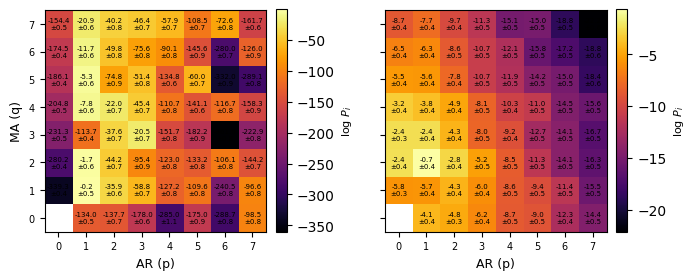

In [ ]:
blazar_evidence_data = ar.EvidenceResults("Heatmap Data/S4_0954+65_evidences.txt",max_p=7)
quasar_evidence_data = ar.EvidenceResults("Heatmap Data/3C_273_evidences.txt",max_p=7)

fig, axes = plt.subplots(
    1, 2,
    figsize=(fig_width_twocol,fig_height_twocol),sharey=True
)
blazar_evidence_data.plot_evidence_heatmap(annotate_fontsize=5,axes=axes[1])
quasar_evidence_data.plot_evidence_heatmap(annotate_fontsize=5,axes=axes[0])
axes[1].set_ylabel("")
fig.savefig("Plots/blazar_heatmap.pdf", bbox_inches="tight", dpi=300, transparent=True, format="pdf")


In [33]:
blazar_pooled_resid = blazar_posteriors.pooled_residuals(deterministic=False).flatten()
quasar_pooled_resid = quasar_posteriors.pooled_residuals(deterministic=False).flatten()

Pooled residuals: 100%|██████████| 1000/1000 [00:00<00:00, 1858.27it/s]


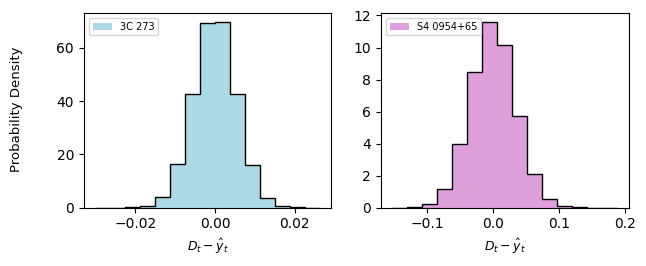

In [34]:
quasar_residual_hist,quasar_residual_ax = plt.subplots(1,2,figsize=(fig_width_twocol,0.6*fig_height_twocol))
quasar_residual_ax[0].hist(quasar_pooled_resid,bins=15,density=True,histtype='step',color='black')
quasar_residual_ax[0].hist(quasar_pooled_resid,bins=15,density=True,color='lightblue',label='3C 273')
quasar_residual_ax[1].hist(blazar_pooled_resid,bins=15,density=True,histtype='step',color='black')
quasar_residual_ax[1].hist(blazar_pooled_resid,bins=15,density=True,color='plum',label='S4 0954+65')
quasar_residual_ax[0].set_xlabel(r'$D_t - \hat{y}_t$',fontsize=fs)
quasar_residual_ax[1].set_xlabel(r'$D_t - \hat{y}_t$',fontsize=fs)
quasar_residual_hist.supylabel('Probability Density',fontsize=9.5)
quasar_residual_ax[0].legend(fontsize=7,loc='upper left')
quasar_residual_ax[1].legend(loc='upper left',fontsize=7)

quasar_residual_hist.savefig("Plots/quasar_resid_hist.pdf",bbox_inches="tight",dpi=300,transparent=True,format="pdf")